# Multi-Layer Perceptron
### Gamma/Neutron Discrimination 

--- 

- Workflow based on R. S. Molina, I. R. Morales, M. L. Crespo, V. G. Costa, S. Carrato and G. Ramponi, "An End-to-End Workflow to Efficiently Compress and Deploy DNN Classifiers on SoC/FPGA", in IEEE Embedded Systems Letters, vol. 16, no. 3, pp. 255-258, Sept. 2024, doi: 10.1109/LES.2023.3343030.

- Code adapted from the official repository of "An End-to-End Workflow to Efficiently Compress and Deploy DNN Classifiers on SoC/FPGA"

- Using open dataset from: https://doi.org/10.5281/zenodo.8037058

----

## Import libraries


In [ ]:
import os
import sys

# Path
sys.path.append(os.path.abspath(".."))

# Core
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn

from numpy import array

import subprocess

from pathlib import Path
import shutil

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras import backend as K
from tensorflow.keras import Sequential
from tensorflow.keras.layers import *
# from tensorflow.keras.layers import Dense, Activation, Input, Dropout, Normalization
from tensorflow.keras.models import *
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l1, l2

# Model optimization
import tensorflow_model_optimization as tfmot
from tensorflow_model_optimization.python.core.sparsity.keras import (
    prune,
    pruning_callbacks,
    pruning_schedule
)
from tensorflow_model_optimization.sparsity.keras import strip_pruning, prune_low_magnitude


# QKeras (Quantization)
from qkeras import *
import tensorflow as tf
from qkeras import QDense, QActivation

# Metrics
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils import shuffle

# Preprocessing
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder

# Dataset split
from sklearn.model_selection import train_test_split

# HLS4ML
import hls4ml

# Reproducibility
tf.random.set_seed(42)

# Clear sessions
K.clear_session()
tf.keras.backend.clear_session()

import sys
sys.path.append(os.path.abspath('../../'))
from common.notebook_utils.distillationClassKeras import Distiller
from common.notebook_utils.utils import report_classifier

2026-04-01 15:41:02.751380: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-01 15:41:02.806876: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-01 15:41:03.637601: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


/tools/anaconda3/envs/neuralEnv/lib/python3.10/site-packages/hls4ml/converters/__init__.py:27: UserWarning: WARNING: Pytorch converter is not enabled!
  warnings.warn("WARNING: Pytorch converter is not enabled!", stacklevel=1)


### Enable GPU 

In [2]:
#  GPU 
os.environ['TF_XLA_FLAGS'] = '--tf_xla_enable_xla_devices'

import tensorflow as tf
print("GPUs: ", len(tf.config.experimental.list_physical_devices('GPU')))

import tensorflow as tf
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)

    except RuntimeError as e:
        print(e)

GPUs:  1


2026-04-01 15:41:05.035503: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-01 15:41:05.089936: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-01 15:41:05.090201: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

## Auxiliar functions

In [3]:
# Function to define the training and testing datasets

def preproc_dataset_(signal_dfN, signal_dfG):
    
    # Label in csv file corresponds to the signal class
    _LABEL_COLUMN = 'class'
    
    # Define training and testing datasets
    dfTest = pd.DataFrame()
    dfTrain = pd.DataFrame()
    
    # Shuffle datasets
    signal_dfN = shuffle(signal_dfN)
    signal_dfG = shuffle(signal_dfG)
    
    # Concatenate datasets
    signal_df = pd.concat([signal_dfN, signal_dfG])
    
    # Split training and testing datasets
    for k in range(0,2):
     
        df2 = signal_df[signal_df[_LABEL_COLUMN].isin([k])]
        
        df_tr = df2[:10000]
        df_t = df2[10001:10900]
        
        dfTrain = pd.concat([df_tr, dfTrain])   
        dfTest = pd.concat([df_t, dfTest])
        
    
    return dfTrain, dfTest

---

## Dataset

In [4]:
# Define path to the dataset for training

PATH = '../00.datasets/'

GAMMA_DATASET_FILE = PATH + 'gamma_label.csv'
NEUTRON_DATASET_FILE = PATH + 'neutron_label.csv'

TEST_DATASET_FILE = PATH + 'test.csv'

In [5]:
# Load datasets in Pandas data frame 

dfGamma = pd.read_csv(GAMMA_DATASET_FILE)
dfNeutron = pd.read_csv(NEUTRON_DATASET_FILE)
dfTestGN = pd.read_csv(TEST_DATASET_FILE)

In [ ]:
# Pre-processing dataset for training 
df_train, dfTest = preproc_dataset_(dfNeutron, dfGamma)

In [ ]:
df_train_ = df_train.pop('class')
dfTest_ = dfTest.pop('class')

# One-hot encoder
le = LabelEncoder()
y = le.fit_transform(df_train_)
y = to_categorical(df_train_, 2)

le = LabelEncoder()
y_test = le.fit_transform(dfTest_)
y_test = to_categorical(dfTest_, 2)

# Split training dataset into training and validation
x_train, x_val, y_train, y_val = train_test_split(df_train, y, test_size=0.2, random_state=51)

---

## Training and compression

For the gamma/neutron discrimination task, knowledge distillation combined with quantization-aware training is employed. A high-capacity teacher network guides the training of a compact student model, enabling the student to approximate the teacher’s decision function while achieving reduced model complexity and high discrimination performance.

- Quantization: Converts floating-point weights and activations into lower-precision formats (e.g., 8-bit or fixed-point). This reduces resource usage and increases inference speed, with a possible trade-off in numerical accuracy.

- Pruning: Removes redundant weights or neurons from the network. Structured or unstructured pruning can significantly reduce model size and computational complexity, though excessive pruning may degrade accuracy.

- Knowledge Distillation: Trains a smaller student model to mimic the behavior of a larger, high-accuracy teacher model. The student learns from the softened outputs of the teacher rather than from labels alone, often achieving competitive accuracy with far fewer parameters. This technique is especially useful when targeting FPGA implementations that require compact, hardware-friendly architectures.

### Teacher training


#### Hyperparameters for the teacher architecture

In [8]:
# Define the hyperparameters for the teacher model
lr = 0.001
neurons_teacher = [13, 15, 7, 5, 6]
batch_t = 32
epochs_t = 32

#### Architecture

In [9]:
# Teacher Model Architecture (MLP - Multi-Layer Perceptron)
# Input:  161 features
# Body:   5 fully-connected layers (Dense + ReLU) with increasing regularization
#         ├─ fc1, fc2: L2 regularization only (prevent overfitting on early layers)
#         ├─ fc3:      L2 + Dropout(0.1)  (light regularization)
#         ├─ fc4:      L2 + Dropout(0.2)  (moderate regularization)
#         └─ fc5:      no L2  + Dropout(0.2)  (final feature extraction)
# Output: 2-class softmax / standard float32 precision (no quantization)
#         The teacher is a full-precision reference model used to guide
#         the training of the smaller, quantized student model


def teacher_topology(bestHP):
    teacher = keras.Sequential(
        [
            Input(shape=(161,), name='inputLayer'),
            Dense(bestHP[0], name='fc1', kernel_regularizer=l2(0.001)),
            Activation('relu', name='relu1'),

            Dense(bestHP[1], name='fc2', kernel_regularizer=l2(0.001)),
            Activation('relu', name='relu2'),

            Dense(bestHP[2], name='fc3', kernel_regularizer=l2(0.001)),
            Activation('relu', name='relu3'),
            Dropout(0.1),

            Dense(bestHP[3], name='fc4', kernel_regularizer=l2(0.001)),
            Activation('relu', name='relu4'),
            Dropout(0.2),

            Dense(bestHP[4], name='fc5', kernel_regularizer=l2(0.001)),
            Activation('relu', name='relu5'),
            Dropout(0.2),

            Dense(2, name='output'),
            Activation('softmax', name='activationOutput'),
        ],
        name="teacher_MLP",
    )

    teacher.summary()
    return teacher


#### Build teacher model

##### Model Compilation

- **loss**: A metric that measures how far the model’s predictions are from the actual values.

- **sparse_categorical_crossentropy**: used when labels are provided as integers.

- **categorical_crossentropy**: used when labels are one-hot encoded.

- **optimizer**: The algorithm that adjusts the neural network's weights to minimize the loss function.

    - SGD (Stochastic Gradient Descent)

    - Adam (Adaptive Moment Estimation — balances speed and stability)

- **learning rate**: A hyperparameter that controls how large the updates to the model’s weights are in each iteration.

- **metrics**: Additional values monitored during training to evaluate model performance.
For example, accuracy is commonly used in classification tasks.

In [10]:
# Function to build the teacher model
def build_teacher(neurons_teacher):

    # Create the teacher model
    model = teacher_topology(neurons_teacher)
    
    # Compile the model
    opt = Adam(lr)
    model.compile(optimizer=opt, loss=['binary_crossentropy'], metrics=['accuracy'])
    
    return model

In [11]:
# Build the teacher model
teacher_model = build_teacher(neurons_teacher)

Model: "teacher_MLP"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 fc1 (Dense)                 (None, 13)                2106      
                                                                 
 relu1 (Activation)          (None, 13)                0         
                                                                 
 fc2 (Dense)                 (None, 15)                210       
                                                                 
 relu2 (Activation)          (None, 15)                0         
                                                                 
 fc3 (Dense)                 (None, 7)                 112       
                                                                 
 relu3 (Activation)          (None, 7)                 0         
                                                                 
 dropout (Dropout)           (None, 7)                 

2026-04-01 15:41:05.626018: I tensorflow/compiler/xla/service/service.cc:169] XLA service 0x7aba1a0 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
2026-04-01 15:41:05.626056: I tensorflow/compiler/xla/service/service.cc:177]   StreamExecutor device (0): Host, Default Version
2026-04-01 15:41:05.626373: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-01 15:41:05.626629: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
202

#### Training of the teacher model

This steps performs the neural network training through `teacher_model.fit()`. 

- _x_ and _y_ are the defined as _x_train_ and _y_train_, respectively. The validation data corresponds to _x_val_ and _y_val_. 

- The batch size is defined as 64, while the number of epochs is 32. 

- Callbacks are used to early stop the training process if no improvement in loss is obtained during training (_EarlyStopping_), and the reduction of the learning rate based on the accuracy metric (_ReduceLROnPlateau_). 

In [12]:
# Callbacks
callbacks = [
            tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, verbose=1, restore_best_weights=True),
            tf.keras.callbacks.ReduceLROnPlateau(monitor='accuracy', factor=0.4, patience=3, verbose=1)
            ] 
# Train the teacher model
history_teacher  = teacher_model.fit(x=x_train, y=y_train,
                  validation_data=(x_val, y_val), 
                  batch_size = batch_t,
                  epochs=epochs_t,
                  callbacks = [callbacks],
                  verbose=1
                  )   


Epoch 1/32


2026-04-01 15:41:07.064475: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-01 15:41:07.080759: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:424] Loaded cuDNN version 8902
2026-04-01 15:41:07.146302: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-04-01 15:41:07.203175: I ./tensorflow/compiler/jit/device_compiler.h:180] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


500/500 [==============================] - 4s 3ms/step - loss: 0.5736 - accuracy: 0.8169 - val_loss: 0.2401 - val_accuracy: 0.9875 - lr: 0.0010
Epoch 2/32
500/500 [==============================] - 1s 2ms/step - loss: 0.3917 - accuracy: 0.8241 - val_loss: 0.0784 - val_accuracy: 0.9812 - lr: 0.0010
Epoch 3/32
500/500 [==============================] - 1s 3ms/step - loss: 0.2715 - accuracy: 0.8675 - val_loss: 0.0738 - val_accuracy: 0.9923 - lr: 0.0010
Epoch 4/32
500/500 [==============================] - 1s 3ms/step - loss: 0.2329 - accuracy: 0.9291 - val_loss: 0.0876 - val_accuracy: 0.9697 - lr: 0.0010
Epoch 5/32
500/500 [==============================] - 1s 3ms/step - loss: 0.2084 - accuracy: 0.9321 - val_loss: 0.0570 - val_accuracy: 0.9950 - lr: 0.0010
Epoch 6/32
500/500 [==============================] - 1s 2ms/step - loss: 0.2014 - accuracy: 0.9269 - val_loss: 0.0541 - val_accuracy: 0.9948 - lr: 0.0010
Epoch 7/32
500/500 [==============================] - 2s 3ms/step - loss: 0.1976 

#### Performance analysis

#### Confusion Matrix

The **confusion matrix** is a useful tool for analyzing the performance of a classification model in terms of accuracy. It presents the prediction results in a matrix format, comparing actual values (true labels) with predicted values.

In a binary classification problem, the confusion matrix is a 2x2 grid with the following components:

- **True Positives (TP):** Number of instances where the model correctly predicted the positive class.

- **True Negatives (TN):** Number of instances where the model correctly predicted the negative class.

- **False Positives (FP):** Number of instances where the model incorrectly predicted the positive class.

- **False Negatives (FN):** Number of instances where the model incorrectly predicted the negative class.


#### ROC Curve

The **Receiver Operating Characteristic (ROC) curve** is a graphical representation used to evaluate the performance of a binary classification model. It plots the **True Positive Rate (TPR)** against the **False Positive Rate (FPR)** at various classification thresholds.

A model with good predictive ability will have a curve that approaches the top-left corner, indicating high sensitivity and low false positive rate. The **Area Under the Curve (AUC)** provides a single scalar value summarizing the overall performance of the classifier.

> Note: The ROC curve is primarily used for binary classification. For multiclass problems, it can be computed using a one-vs-rest (OvR) strategy.



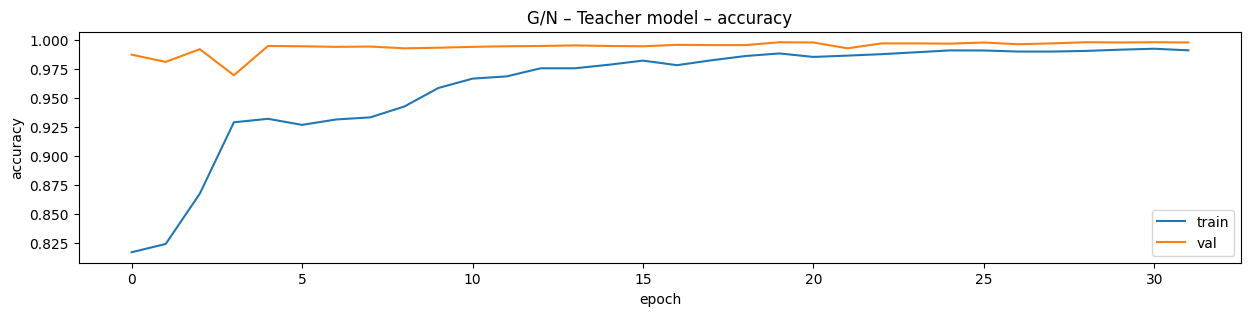

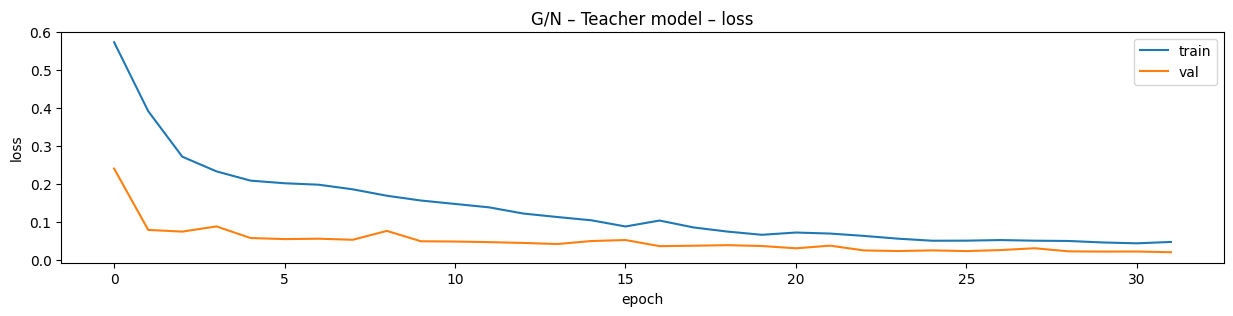

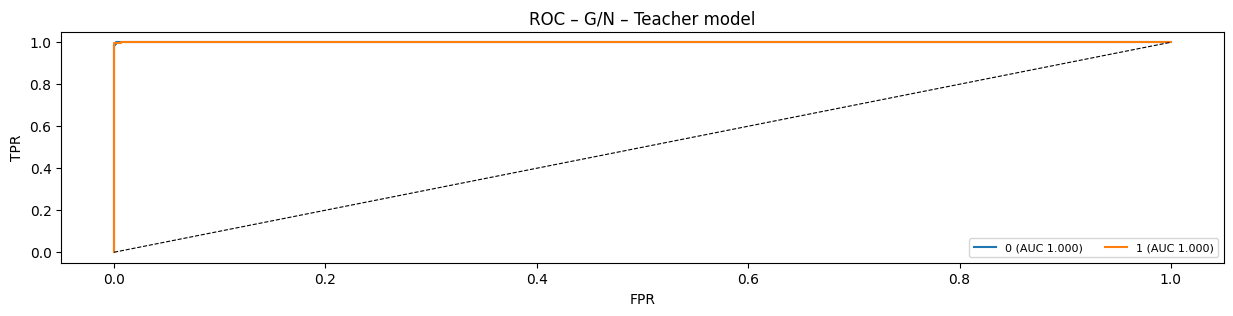

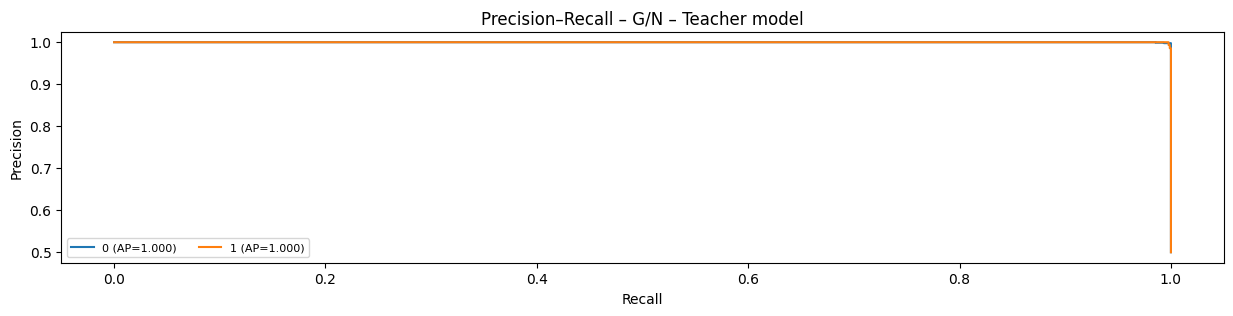

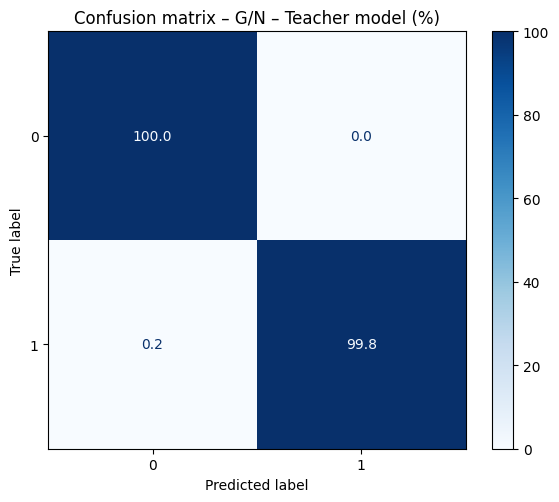

In [36]:
figs, aucs, metrics = report_classifier(
    history=history_teacher,         
    y_true=np.argmax(y_test, axis=1),  
    y_proba=teacher_model.predict(dfTest, batch_size=256, verbose=0),
    class_names=[str(i) for i in range(y_test.shape[1])],  
    model_name="G/N – Teacher model",
    threshold=0.5,             
    save_prefix=None,
    show = True
)


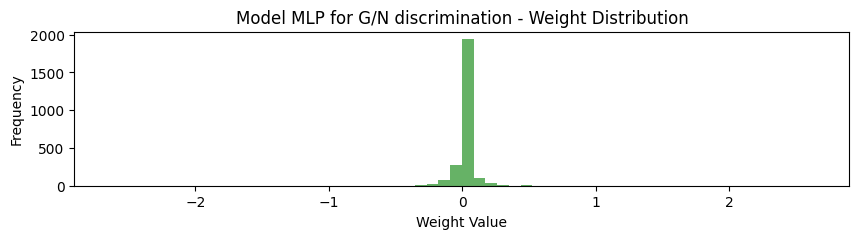

In [14]:
# Observe the weight distribution

weights = np.concatenate([w.flatten() for w in teacher_model.get_weights()])

plt.figure(figsize=(10,2))
plt.hist(weights, bins=60, color='green', alpha=0.6)
plt.xlabel("Weight Value")
plt.ylabel("Frequency")
plt.title("Model MLP for G/N discrimination - Weight Distribution")
plt.show()



#### Save teacher model

In [15]:
# If needed, save the teacher model [uncomment the following line]
teacher_model.save('./models/teacherModel_GN.h5')

----

### Student training

The student model is defined using quantization and pruning strategies.  

For the gamma/neutron task, the number of bits was set to eight, and the target sparsity was set to 50%. 

**Qkeras** is employed to define the student model in a quantized manner. 

**For more information regarding QKeras:** Coelho, C. N., Kuusela, A., Zhuang, H., Aarrestad, T., Loncar, V., Ngadiuba, J., ... & Summers, S. (2020). _Ultra low-latency, low-area inference accelerators using heterogeneous deep quantization with QKeras and hls4ml_. arXiv preprint arXiv:2006.10159, 108.

#### Hyperparameters for the student model

In [16]:
# Define the hyperparameters for the student model
lr = 0.0001
neurons_student = [5, 4, 4, 5, 3]

batch_s = 64
epochs_s= 32
validation_split = 0.2


#### Define student architecture

In [17]:
# Student Model Architecture

# Input: 161 features
# Body:  5 quantized fully-connected blocks (QDense + QActivation + Dropout)
#        └─ Hidden layers use 8-bit fixed-point quantization (weights & activations)
#           to reduce model size and enable efficient FPGA inference via hls4ml
# Output: 2-class softmax (16-bit quantized dense → standard softmax activation)
#         The output layer uses higher precision (16-bit) to preserve classification accuracy


def student_architecture(neurons_student):

    kernelQ = "quantized_bits(8,4)"
    biasQ = "quantized_bits(8,4)"
    activationQ = "quantized_bits(8)"          
    kernelQ_16b = "quantized_bits(16,6)"
    biasQ_16b = "quantized_bits(16,6)"

    inp = Input(shape=(161,), name='inputLayer')

    fc1 = QDense(neurons_student[0], name='fc1',
                 kernel_quantizer=kernelQ, bias_quantizer=biasQ,
                 kernel_initializer='lecun_uniform')(inp)
    relu0 = QActivation(activation=activationQ, name='relu0')(fc1)
    d1 = Dropout(0.1)(relu0)

    fc2 = QDense(neurons_student[1], name='fc2',
                 kernel_quantizer=kernelQ, bias_quantizer=biasQ,
                 kernel_initializer='lecun_uniform')(d1)
    relu1 = QActivation(activation=activationQ, name='relu1')(fc2)
    d2 = Dropout(0.1)(relu1)

    fc3 = QDense(neurons_student[2], name='fc3',
                 kernel_quantizer=kernelQ, bias_quantizer=biasQ,
                 kernel_initializer='lecun_uniform')(d2)
    relu2 = QActivation(activation=activationQ, name='relu2')(fc3)
    d3 = Dropout(0.1)(relu2)

    fc4 = QDense(neurons_student[3], name='fc4',
                 kernel_quantizer=kernelQ, bias_quantizer=biasQ,
                 kernel_initializer='lecun_uniform')(d3)
    relu3 = QActivation(activation=activationQ, name='relu3')(fc4)
    d4 = Dropout(0.1)(relu3)

    fc5 = QDense(neurons_student[4], name='fc5',
                 kernel_quantizer=kernelQ, bias_quantizer=biasQ,
                 kernel_initializer='lecun_uniform')(d4)
    relu4 = QActivation(activation=activationQ, name='relu4')(fc5)
    d5 = Dropout(0.1)(relu4)

    out_dense = QDense(2, name='output',
                       kernel_quantizer=kernelQ_16b, bias_quantizer=biasQ_16b,
                       kernel_initializer='lecun_uniform')(d5)
    out = Activation('softmax', name='outputActivation')(out_dense)

    return Model(inputs=inp, outputs=out, name='student')


#### Build student model

In [18]:

def build_student(qmodel, x_train_size, batch_size, epochs):

    # --- Pruning Schedule Setup ---
    steps_per_epoch    = int(np.ceil(x_train_size / batch_size))
    warmup_epochs      = 5                                              # Epochs before pruning begins
    finish_margin_ep   = 10                                             # Pruning stops N epochs before end
    finish_prune_epoch = max(warmup_epochs + 1, epochs - finish_margin_ep)

    begin_step = warmup_epochs      * steps_per_epoch   # Step where pruning starts
    end_step   = finish_prune_epoch * steps_per_epoch   # Step where pruning ends

    # PolynomialDecay: gradually increases sparsity from 0% to 40% between begin_step and end_step
    pruning_schedule = tfmot.sparsity.keras.PolynomialDecay(
        initial_sparsity = 0.0,          # No weights pruned at the start
        final_sparsity   = 0.4,          # 40% of weights zeroed out by end_step
        begin_step       = begin_step,
        end_step         = end_step,
        frequency        = steps_per_epoch   # Pruning mask updated once per epoch
    )

    # --- Apply Pruning to Quantized Layers ---
    # Pruning is applied to both Dense and QDense layers, since the student
    # model uses QKeras layers throughout its architecture
    def apply_pruning_to_layer(layer):
        if isinstance(layer, (tf.keras.layers.Dense, QDense)):
            return prune_low_magnitude(layer, pruning_schedule=pruning_schedule)
        return layer    # Leave all other layers (Dropout, Activation, etc.) unchanged

    # Clone the quantized model, wrapping Dense/QDense layers with pruning
    studentQ = tf.keras.models.clone_model(qmodel, clone_function=apply_pruning_to_layer)

    return studentQ

#### Compile student model for KD + QAT

In [19]:
# Define the student architecture
qmodel = student_architecture(neurons_student)
# Build the student model
studentQ = build_student(qmodel,  x_train.shape[0], batch_s, epochs_s)

studentQ.summary()

Model: "student"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 inputLayer (InputLayer)     [(None, 161)]             0         
                                                                 
 prune_low_magnitude_fc1 (Pr  (None, 5)                1617      
 uneLowMagnitude)                                                
                                                                 
 relu0 (QActivation)         (None, 5)                 0         
                                                                 
 dropout_3 (Dropout)         (None, 5)                 0         
                                                                 
 prune_low_magnitude_fc2 (Pr  (None, 4)                46        
 uneLowMagnitude)                                                
                                                                 
 relu1 (QActivation)         (None, 4)                 0   

In [ ]:
# Knowledge Distillation Process

# We now configure and compile the `Distiller` model to begin the knowledge distillation process.
# Key Components:

    # - optimizer: Uses the Adam optimizer with a low learning rate (1e-3) for stable training.
    # - metrics: Monitors the student's classification performance using SparseCategoricalAccuracy.
    # - student_loss_fn: The loss between the student model's predictions and the true labels.
    # - distillation_loss_fn: KL Divergence loss between the teacher and student outputs (soft targets).
    # - alpha: Balancing factor between the student loss and the distillation loss (e.g., 0.1 = mostly focus on soft targets).
    # - temperature: Softens the output probabilities of the teacher (higher = softer), allowing the student to learn richer patterns.

# This setup enables the student model to learn both from the actual labels and from the teacher's knowledge, improving efficiency and generalization

distilled_student = Distiller(student=studentQ, teacher=teacher_model)

# Define the optimizer
adam = Adam(lr)

train_labels = np.argmax(y_train, axis=1)

# Compile the student
distilled_student.compile(
        optimizer=adam,
        metrics=[keras.metrics.SparseCategoricalAccuracy()],
        student_loss_fn=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
        distillation_loss_fn=keras.losses.KLDivergence(),
        alpha=0.1, 
        temperature=10,
    )

#### Training of the student model

In [ ]:

# Define the callbacks
callbacks = [
                # tf.keras.callbacks.EarlyStopping(monitor='sparse_categorical_accuracy', patience=10, verbose=1),
                tf.keras.callbacks.ReduceLROnPlateau(monitor='sparse_categorical_accuracy', factor=0.3, patience=10, verbose=1),
                pruning_callbacks.UpdatePruningStep()
                ]  

# Train the student
history_studentQPKD = distilled_student.fit(x_train, train_labels, 
                               batch_size = batch_s, 
                               epochs = epochs_s, 
                               validation_split = validation_split,
                               callbacks = callbacks
                               )

Epoch 1/32
200/200 [==============================] - 13s 20ms/step - sparse_categorical_accuracy: 0.7105 - student_loss: 0.5378 - distillation_loss: 8.9898e-04 - val_sparse_categorical_accuracy: 0.9787 - val_student_loss: 0.2982 - lr: 1.0000e-04
Epoch 2/32
200/200 [==============================] - 3s 13ms/step - sparse_categorical_accuracy: 0.8309 - student_loss: 0.3756 - distillation_loss: 5.5732e-04 - val_sparse_categorical_accuracy: 0.9912 - val_student_loss: 0.2115 - lr: 1.0000e-04
Epoch 3/32
200/200 [==============================] - 3s 13ms/step - sparse_categorical_accuracy: 0.8779 - student_loss: 0.2957 - distillation_loss: 4.0047e-04 - val_sparse_categorical_accuracy: 0.9747 - val_student_loss: 0.1887 - lr: 1.0000e-04
Epoch 4/32
200/200 [==============================] - 3s 13ms/step - sparse_categorical_accuracy: 0.8828 - student_loss: 0.2808 - distillation_loss: 3.7234e-04 - val_sparse_categorical_accuracy: 0.9669 - val_student_loss: 0.1701 - lr: 1.0000e-04
Epoch 5/32
200/

#### Performance analysis

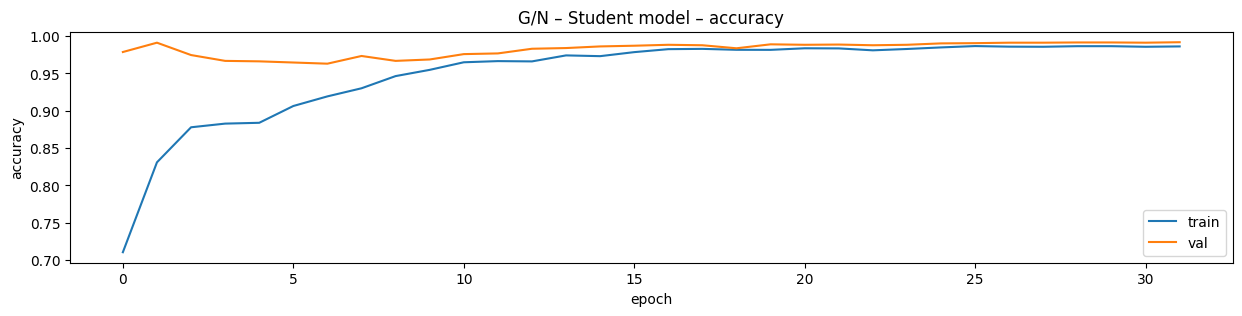

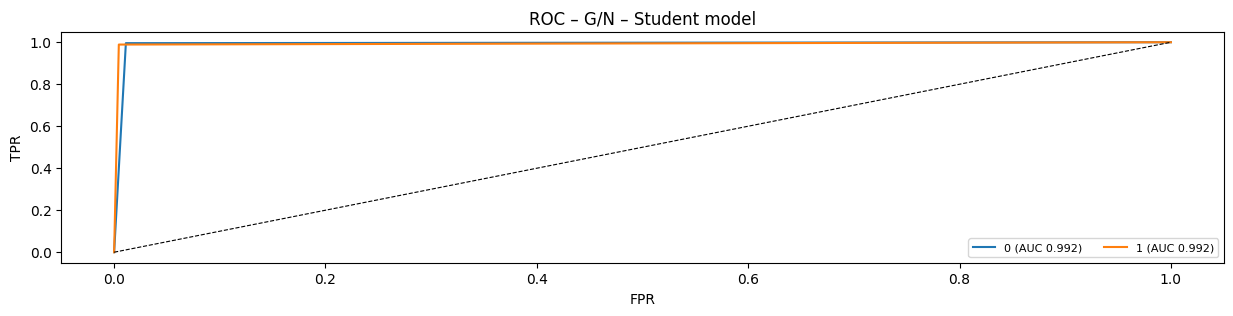

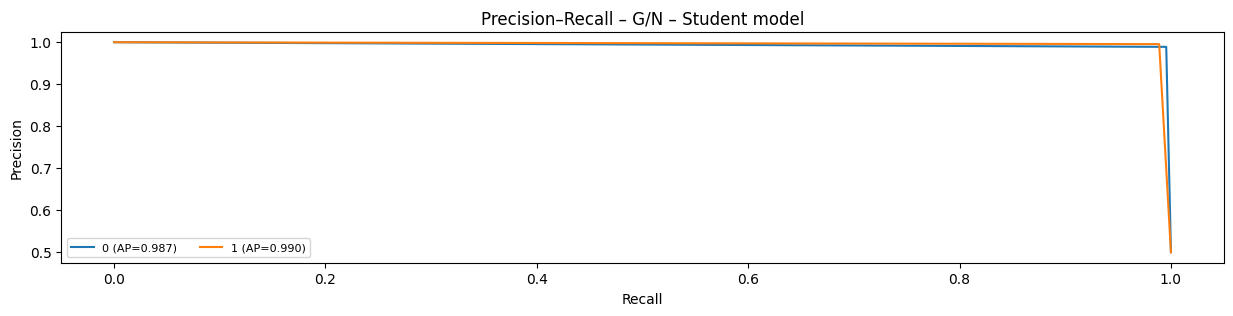

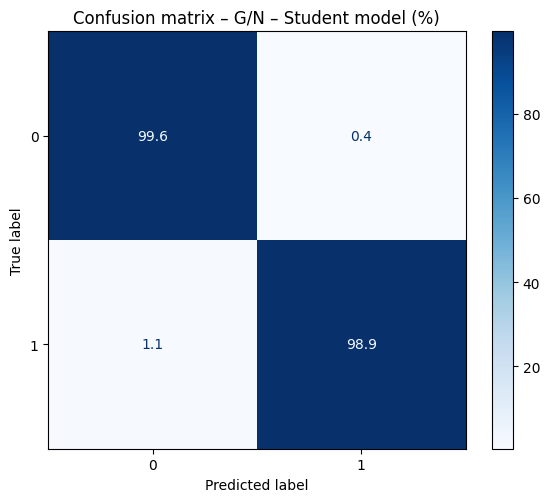

In [ ]:
figs, aucs, metrics = report_classifier(
    history=history_studentQPKD,         
    y_true=np.argmax(y_test, axis=1),  
    y_proba=distilled_student.student.predict(dfTest, batch_size=256, verbose=0),
    class_names=[str(i) for i in range(y_test.shape[1])],  
    model_name="G/N – Student model",
    threshold=0.5,             
    save_prefix=None,
    show = True
)


Weight distribution after pruning

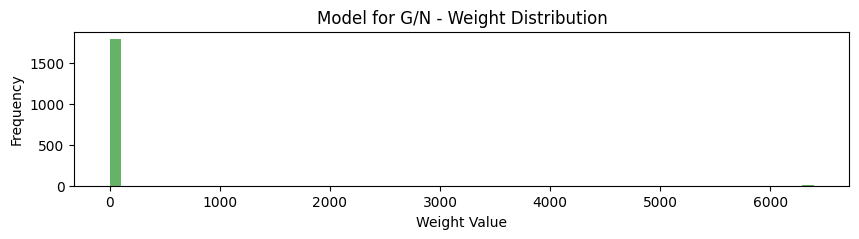

In [23]:
# Obtain the weight distribution
weights = np.concatenate([w.flatten() for w in distilled_student.student.get_weights()])

plt.figure(figsize=(10,2))
plt.hist(weights, bins=60, color='green', alpha=0.6)
plt.xlabel("Weight Value")
plt.ylabel("Frequency")
plt.title("Model for G/N - Weight Distribution")
plt.show()


#### Test single prediction

Test the model for single inputs. 

The variable **indexPrediction** corresponds to the signals' index  in the testing dataset. You can change this number to observe how the ML-based model predicts for specific inputs. 

1/1 [==============================] - 0s 32ms/step
> Input [1. 0.] -> Predicted = [[0.9821666  0.01783338]] | 


Text(0.5, 1.0, 'Signal used for inference - Pulse: 1500, Label: [1. 0.], Prediction: [[0.9821666  0.01783338]]')

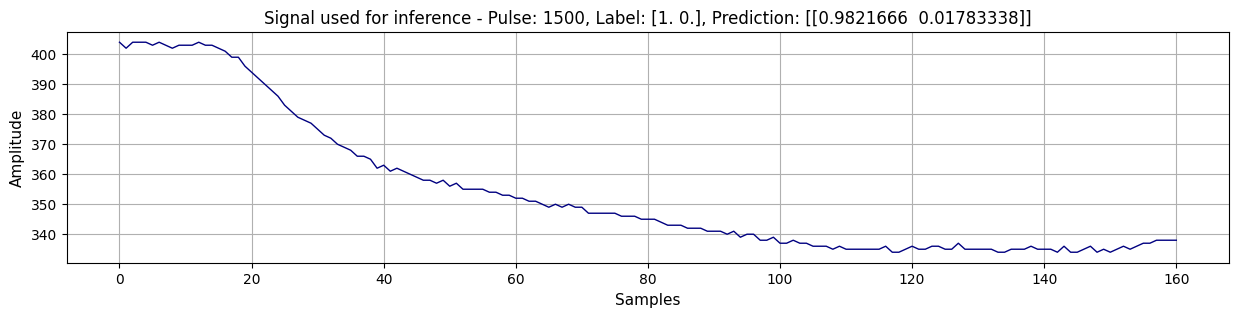

In [25]:
# Index of the signal in the testing dataset
indexPrediction = 1500

x_input = dfTest.iloc[indexPrediction]
y_label = y_test[indexPrediction]

inputPred = array([x_input])

y_pred = distilled_student.student.predict(inputPred) 
print("> Input %s -> Predicted = %s | " % (y_label, y_pred))

plt.figure(figsize=(15,3))
plt.xlabel('Samples', fontsize=11)
plt.ylabel('Amplitude', fontsize=11)
plt.grid(True, alpha=1.0)
plt.plot(x_input.values,  label="Signal 1", color='navy', markersize=7, lw=1)

plt.title('Signal used for inference - Pulse: %s, Label: %s, Prediction: %s' % (indexPrediction, y_label, y_pred))

#### Save student model

In [26]:
# strip_pruning removes all pruning-related wrapper layers and metadata that were added during training (e.g. pruning masks, step counters).
# The result is a clean, lightweight model where pruned weights remain as zeros, reducing model complexity without affecting the learned sparsity.
model = strip_pruning(distilled_student.student)
model.summary()



Model: "student"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 inputLayer (InputLayer)     [(None, 161)]             0         
                                                                 
 fc1 (QDense)                (None, 5)                 810       
                                                                 
 relu0 (QActivation)         (None, 5)                 0         
                                                                 
 dropout_3 (Dropout)         (None, 5)                 0         
                                                                 
 fc2 (QDense)                (None, 4)                 24        
                                                                 
 relu1 (QActivation)         (None, 4)                 0         
                                                                 
 dropout_4 (Dropout)         (None, 4)                 0   

In [27]:
# Save the stripped model to disk in HDF5 (.h5) format.
# This file contains the full model architecture, weights, and optimizer state, ready for inference or deployment

model.save('./models/studentModel_GN.h5')

----

With the training pipeline complete, the next notebook covers the HLS/ML workflow: from HLS4ML conversion to IP core generation.

**Next step:** Proceed to the next notebook *02.hls4ml/mlp-hls4ml.ipynb*.

---

This work was supported in part by the [AMD University Program](https://www.amd.com/en/corporate/university-program.html) 